In [ ]:
!pip install kaggle

In [ ]:
! mkdir ~/.kaggle

In [ ]:
cp kaggle.json ~/.kaggle/

In [ ]:
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d preetviradiya/brian-tumor-dataset

Dataset URL: https://www.kaggle.com/datasets/preetviradiya/brian-tumor-dataset
License(s): GPL-2.0
 83% 89.0M/107M [00:00<00:00, 245MB/s]
100% 107M/107M [00:00<00:00, 218MB/s] 


In [ ]:
! unzip brian-tumor-dataset.zip

Archive:  brian-tumor-dataset.zip
  inflating: Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor/Cancer (1).jpg  
  inflating: Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor/Cancer (1).png  
  inflating: Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor/Cancer (1).tif  
  inflating: Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor/Cancer (10).jpg  
  inflating: Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor/Cancer (10).tif  
  inflating: Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor/Cancer (100).jpg  
  inflating: Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor/Cancer (1000).jpg  
  inflating: Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor/Cancer (1001).jpg  
  inflating: Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor/Cancer (1002).JPG  
  inflating: Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor/Cancer (1003).jpg  
  inflating: Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor/Cancer (1004).jpg  
  inflating: Brain Tumo

In [ ]:
import numpy as np
import pandas as pd
import cv2 as cv
import matplotlib.pyplot as plt
import random
import os
import seaborn as sns

In [ ]:
data_dir = ('Brain Tumor Data Set/Brain Tumor Data Set/')
print(data_dir)

Brain Tumor Data Set/Brain Tumor Data Set/


In [ ]:
classes = os.listdir(data_dir)
classes

['Healthy', 'Brain Tumor']

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.preprocessing.image import ImageDataGenerator

In [ ]:
gen = ImageDataGenerator(rescale=1./255,validation_split = 0.2, dtype= float)

In [ ]:
train = gen.flow_from_directory(data_dir,
                               target_size = (150,150),
                               batch_size = 256,
                               class_mode = "binary",
                               color_mode = "rgb",
                               shuffle = True,
                               seed = 123,
                               subset = "training")

Found 3681 images belonging to 2 classes.


In [ ]:
val = gen.flow_from_directory(data_dir,
                               target_size = (150,150),
                               batch_size = 1,
                               class_mode = "binary",
                               color_mode = "rgb",
                               shuffle = True,
                               seed = 123,
                               subset = "validation")
classes = val.class_indices

Found 919 images belonging to 2 classes.


In [ ]:
classes

{'Brain Tumor': 0, 'Healthy': 1}

Text(0.5, 1.0, 'Healthy')

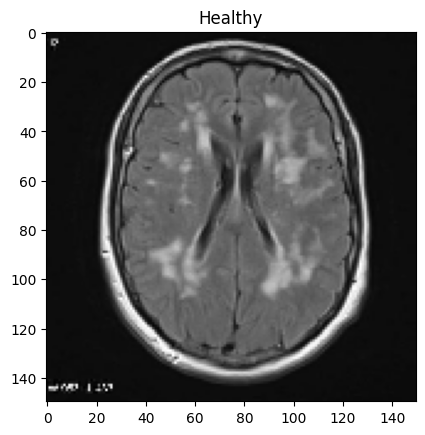

In [ ]:
import matplotlib.pyplot as plt
batch = next(train)

plt.imshow(batch[0][0])

tit = 'Brain_Tumor'
if batch[1][0] == 1:
    tit = 'Healthy'
plt.title(tit)

Text(0.5, 1.0, 'Healthy')

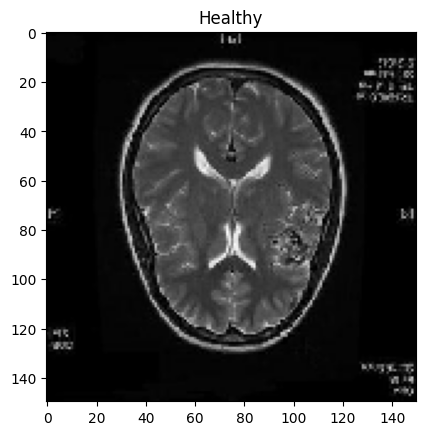

In [ ]:
plt.imshow(batch[0][4])

tit = 'Brain_Tumor'
if batch[1][4] == 1:
    tit = 'Healthy'
plt.title(tit)

In [ ]:
batch[0][0]

array([[[0.04705883, 0.04705883, 0.04705883],
        [0.04705883, 0.04705883, 0.04705883],
        [0.04705883, 0.04705883, 0.04705883],
        ...,
        [0.04705883, 0.04705883, 0.04705883],
        [0.04705883, 0.04705883, 0.04705883],
        [0.04705883, 0.04705883, 0.04705883]],

       [[0.04705883, 0.04705883, 0.04705883],
        [0.04705883, 0.04705883, 0.04705883],
        [0.04705883, 0.04705883, 0.04705883],
        ...,
        [0.04705883, 0.04705883, 0.04705883],
        [0.04705883, 0.04705883, 0.04705883],
        [0.04705883, 0.04705883, 0.04705883]],

       [[0.04705883, 0.04705883, 0.04705883],
        [0.04705883, 0.04705883, 0.04705883],
        [0.04705883, 0.04705883, 0.04705883],
        ...,
        [0.04705883, 0.04705883, 0.04705883],
        [0.04705883, 0.04705883, 0.04705883],
        [0.04705883, 0.04705883, 0.04705883]],

       ...,

       [[0.04705883, 0.04705883, 0.04705883],
        [0.04313726, 0.04313726, 0.04313726],
        [0.03921569, 0

In [ ]:
batch

(array([[[[0.04705883, 0.04705883, 0.04705883],
          [0.04705883, 0.04705883, 0.04705883],
          [0.04705883, 0.04705883, 0.04705883],
          ...,
          [0.04705883, 0.04705883, 0.04705883],
          [0.04705883, 0.04705883, 0.04705883],
          [0.04705883, 0.04705883, 0.04705883]],
 
         [[0.04705883, 0.04705883, 0.04705883],
          [0.04705883, 0.04705883, 0.04705883],
          [0.04705883, 0.04705883, 0.04705883],
          ...,
          [0.04705883, 0.04705883, 0.04705883],
          [0.04705883, 0.04705883, 0.04705883],
          [0.04705883, 0.04705883, 0.04705883]],
 
         [[0.04705883, 0.04705883, 0.04705883],
          [0.04705883, 0.04705883, 0.04705883],
          [0.04705883, 0.04705883, 0.04705883],
          ...,
          [0.04705883, 0.04705883, 0.04705883],
          [0.04705883, 0.04705883, 0.04705883],
          [0.04705883, 0.04705883, 0.04705883]],
 
         ...,
 
         [[0.04705883, 0.04705883, 0.04705883],
          [0.04313

In [ ]:
batch[0][0].shape

(150, 150, 3)

In [ ]:
import keras
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Dense, Flatten
from keras.models import Sequential
from keras.losses import BinaryCrossentropy
from keras.optimizers import Adam
from tensorflow.keras.utils import plot_model

In [ ]:
model = Sequential()
model.add(Conv2D(6, kernel_size=(5, 5), activation='relu', input_shape=(150, 150, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(16, kernel_size=(5, 5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(80, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(optimizer=Adam(0.001),loss = BinaryCrossentropy(),metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 146, 146, 6)       456       
                                                                 
 max_pooling2d (MaxPooling2  (None, 73, 73, 6)         0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 69, 69, 16)        2416      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 34, 34, 16)        0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 18496)             0         
                                                                 
 dense (Dense)               (None, 80)                1

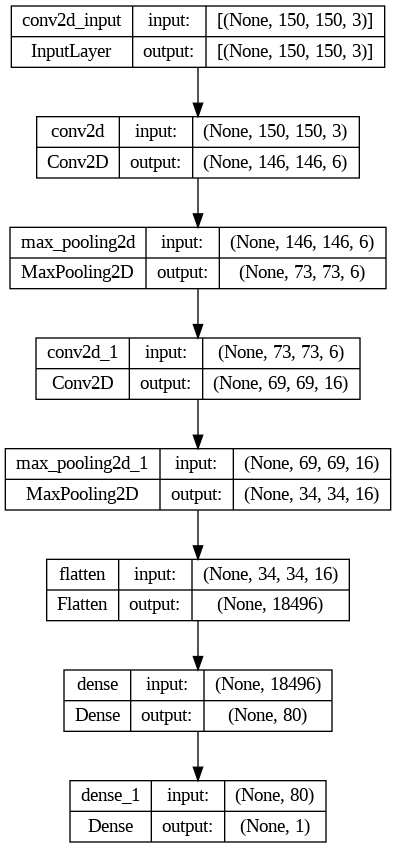

In [ ]:
tf.keras.utils.plot_model(
    model, to_file='model.png', show_shapes=True,
    show_layer_names=True,
)

In [ ]:
histroy1 = model.fit(train, epochs=5, verbose=1, validation_data=(val))

Epoch 1/5
15/15 [==============================] - 18s 793ms/step - loss: 0.6420 - accuracy: 0.6262 - val_loss: 0.5217 - val_accuracy: 0.7867
Epoch 2/5
15/15 [==============================] - 18s 1s/step - loss: 0.4806 - accuracy: 0.7816 - val_loss: 0.3621 - val_accuracy: 0.8520
Epoch 3/5
15/15 [==============================] - 18s 1s/step - loss: 0.3256 - accuracy: 0.8634 - val_loss: 0.2692 - val_accuracy: 0.8912
Epoch 4/5
15/15 [==============================] - 12s 820ms/step - loss: 0.2185 - accuracy: 0.9190 - val_loss: 0.1994 - val_accuracy: 0.9206
Epoch 5/5
15/15 [==============================] - 12s 810ms/step - loss: 0.1516 - accuracy: 0.9470 - val_loss: 0.1418 - val_accuracy: 0.9478


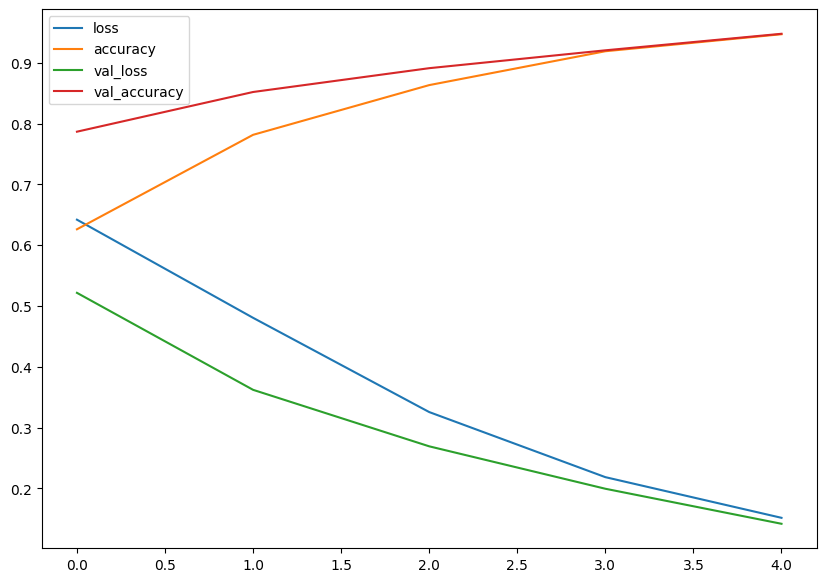

In [ ]:
import pandas as pd
pd.DataFrame(histroy1.history).plot(figsize=(10, 7));

In [ ]:
def prediction(img):
    predictions = model.predict(img)
    pred = predictions[0][0]  # Get the prediction value

    if pred > 0.5:
        predicted_class = list(classes.keys())[list(classes.values()).index(0)]
    else:
        predicted_class = list(classes.keys())[list(classes.values()).index(1)]

    plt.imshow(img[0])
    plt.axis('off')
    plt.title(f'Predicted Class: {predicted_class}')
    plt.show()

    return predicted_class

1/1 [==============================] - 0s 158ms/step


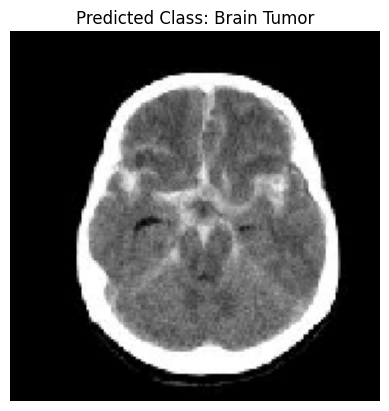

'Brain Tumor'

In [ ]:
pred_img = next(val)[0]

prediction(pred_img)

1/1 [==============================] - 0s 68ms/step


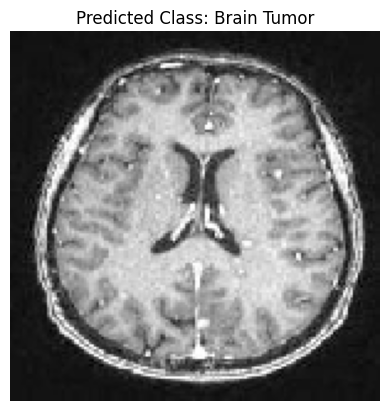

'Brain Tumor'

In [ ]:
pred_img = next(val)[0]

prediction(pred_img)

LIME


In [ ]:

import numpy as np
import keras
from keras.applications.imagenet_utils import decode_predictions
import skimage.io
import skimage.segmentation
import copy
import sklearn
import sklearn.metrics
from sklearn.linear_model import LinearRegression
import warnings

print('Notebook running: keras ', keras.__version__)
np.random.seed(222)

Notebook running: keras  2.15.0


In [ ]:
import cv2
def prediction(path):
    Xi = cv2.imread(path)
    print(Xi.shape)
    resized_image = cv2.resize(Xi, (150, 150))
    print(resized_image.size, resized_image.shape)
    reshaped_image = np.reshape(resized_image, (1, 150, 150, 3))
    predictions = model.predict(reshaped_image)
    pred = predictions[0][0]  # Get the prediction value

    if pred > 0.5:
        pred = 1
        predicted_class = list(classes.keys())[list(classes.values()).index(0)]
    else:
        predicted_class = list(classes.keys())[list(classes.values()).index(1)]
        pred = 0
    return [pred]

np.random.seed(222)
preds = prediction('/content/test.jpg')
if preds[-1] == 0:
  preds.append(1)
else:
  preds.append(0)

(238, 220, 3)
67500 (150, 150, 3)
1/1 [==============================] - 0s 75ms/step


In [ ]:
top_pred_classes = preds
top_pred_classes

[0, 1]

In [ ]:
Xi = cv2.imread('/content/test.jpg')
Xi = skimage.transform.resize(Xi, (150,150))
# reshaped_image = np.reshape(resized_image, (1, 150, 150, 3))
# Xi = reshaped_image

In [ ]:
superpixels = skimage.segmentation.quickshift(Xi, kernel_size=4,max_dist=200, ratio=0.2)
num_superpixels = np.unique(superpixels).shape[0]
num_superpixels

9

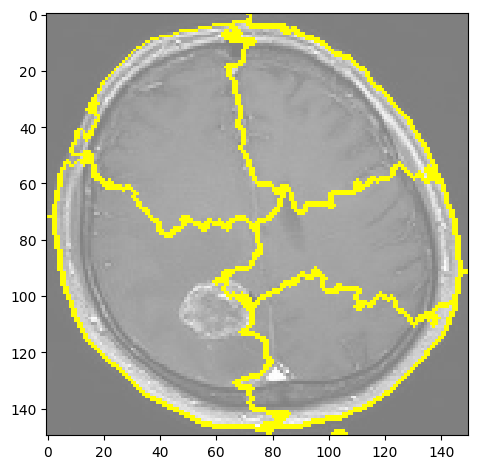

In [ ]:
skimage.io.imshow(skimage.segmentation.mark_boundaries(Xi/2+0.5, superpixels))

In [ ]:
num_perturb = 150
perturbations = np.random.binomial(1, 0.5, size=(num_perturb, num_superpixels))
perturbations[0]

array([1, 1, 1, 1, 0, 0, 1, 0, 1])

In [ ]:
def perturb_image(img,perturbation,segments):
  active_pixels = np.where(perturbation == 1)[0]
  mask = np.zeros(segments.shape)
  for active in active_pixels:
      mask[segments == active] = 1
  perturbed_image = copy.deepcopy(img)
  perturbed_image = perturbed_image*mask[:,:,np.newaxis]
  return perturbed_image

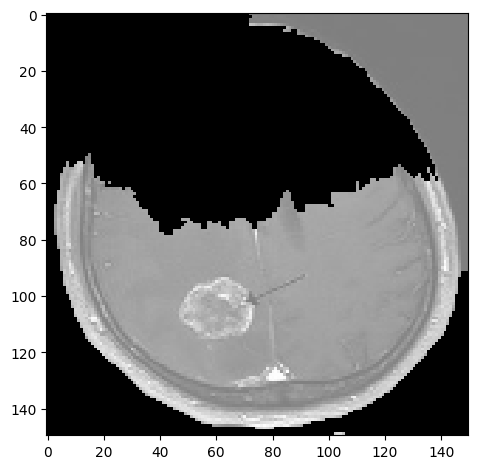

In [ ]:
skimage.io.imshow(perturb_image(Xi/2+0.5,perturbations[1],superpixels))

In [ ]:
predictions = []
for pert in perturbations:
  perturbed_img = perturb_image(Xi,pert,superpixels)
  pred = model.predict(perturbed_img[np.newaxis,:,:,:])
  predictions.append(pred)

predictions = np.array(predictions)
predictions.shape

1/1 [==============================] - 0s 16ms/step


(150, 1, 1)

In [ ]:
predictions[0].shape

(1, 1)

In [ ]:
original_image = np.ones(num_superpixels)[np.newaxis,:]
distances = sklearn.metrics.pairwise_distances(perturbations,original_image, metric='cosine').ravel()
distances.shape

(150,)

In [ ]:
kernel_width = 0.25
weights = np.sqrt(np.exp(-(distances**2)/kernel_width**2))
weights.shape

(150,)

In [ ]:
class_to_explain = top_pred_classes[0]
simpler_model = LinearRegression()
simpler_model.fit(X=perturbations, y=predictions[:,:,class_to_explain], sample_weight=weights)
coeff = simpler_model.coef_[0]
coeff

array([-0.01080098, -0.01177715, -0.05746212, -0.00259686,  0.05746767,
       -0.1653317 , -0.12682145,  0.00638866,  0.00907289])

In [ ]:
num_top_features = 1
top_features = np.argsort(coeff)[-num_top_features:]
top_features

array([4])

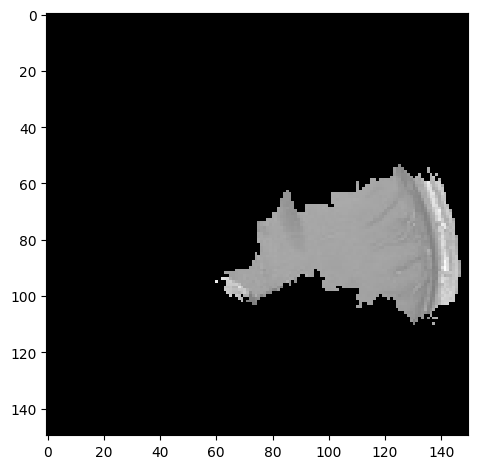

In [ ]:
mask = np.zeros(num_superpixels)
mask[top_features]= True
skimage.io.imshow(perturb_image(Xi/2+0.5,mask,superpixels) )